In [1]:
import pandas as pd

df = pd.read_csv("student-mat.csv", sep=";")

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

In [3]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [4]:
df[["studytime", "absences", "failures", "G3"]].describe()

,studytime,absences,failures,G3
count,395.000000,395.000000,395.000000,395.000000
mean,2.035443,5.708861,0.334177,10.415190
std,0.839240,8.003096,0.743651,4.581443
min,1.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,8.000000
50%,2.000000,4.000000,0.000000,11.000000
75%,2.000000,8.000000,0.000000,14.000000
max,4.000000,75.000000,3.000000,20.000000


In [5]:
df["studytime"].value_counts().sort_index()

studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

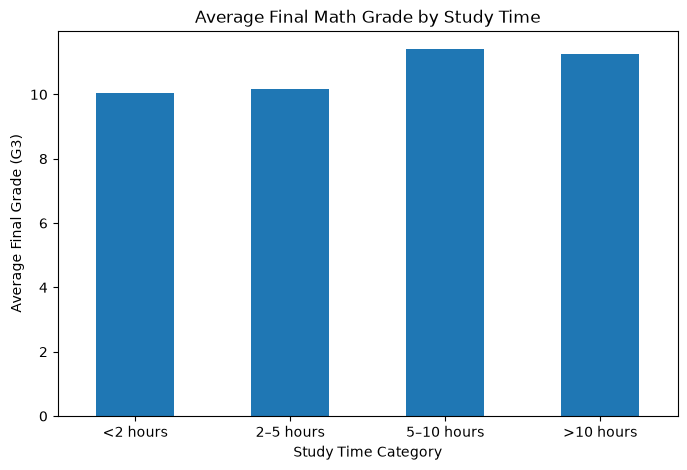

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df.groupby("studytime")["G3"].mean().plot(kind="bar")

plt.title("Average Final Math Grade by Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=["<2 hours", "2–5 hours", "5–10 hours", ">10 hours"],
    rotation=0
)

plt.show()

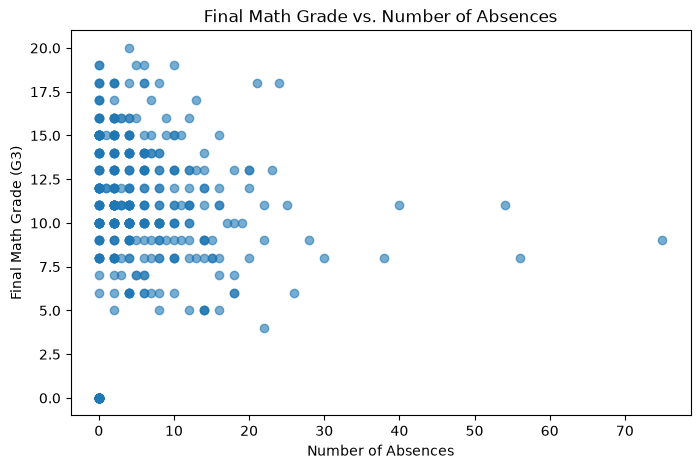

In [7]:
plt.figure(figsize=(8, 5))

plt.scatter(df["absences"], df["G3"], alpha=0.6)

plt.title("Final Math Grade vs. Number of Absences")
plt.xlabel("Number of Absences")
plt.ylabel("Final Math Grade (G3)")

plt.show()

In [9]:
df[["studytime", "absences", "failures", "G3"]].corr()

,studytime,absences,failures,G3
studytime,1.000000,-0.062700,-0.173563,0.097820
absences,-0.062700,1.000000,0.063726,0.034247
failures,-0.173563,0.063726,1.000000,-0.360415
G3,0.097820,0.034247,-0.360415,1.000000


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

X = df[["studytime", "absences", "failures"]]
y = df["G3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred) ** 0.5)

R²: 0.03074152988683987
RMSE: 4.458103940538365


In [14]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, "coefficient:", coefficient)

Intercept: 9.792179759530896
studytime coefficient: 0.5131770074191027
absences coefficient: 0.04129383185056574
failures coefficient: -2.268005830613942


In [15]:
df["passed"] = (df["G3"] >= 10).astype(int)

df["passed"].value_counts()

passed
1    265
0    130
Name: count, dtype: int64

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df[["studytime", "absences", "failures"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7341772151898734

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.33      0.46        27
           1       0.73      0.94      0.82        52

    accuracy                           0.73        79
   macro avg       0.74      0.64      0.64        79
weighted avg       0.74      0.73      0.70        79



In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df[["studytime", "absences", "failures"]]
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.759493670886076

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.41      0.54        27
           1       0.75      0.94      0.84        52

    accuracy                           0.76        79
   macro avg       0.77      0.67      0.69        79
weighted avg       0.76      0.76      0.73        79



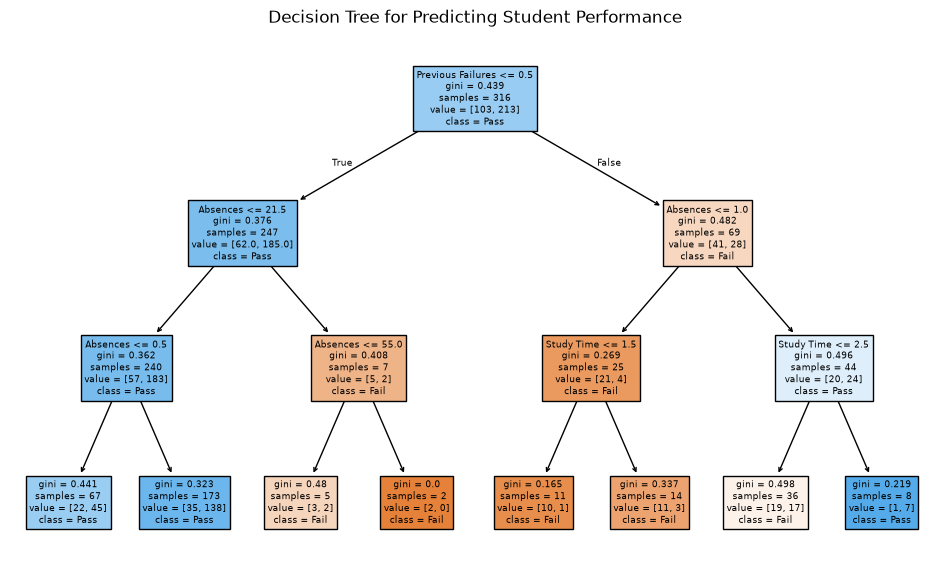

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

plot_tree(
    tree_model,
    feature_names=["Study Time", "Absences", "Previous Failures"],
    class_names=["Fail", "Pass"],
    filled=True
)

plt.title("Decision Tree for Predicting Student Performance")
plt.show()

# Student Performance Analysis

## Research Question

How do study time, absences, and previous class failures relate to students' final math grades?

This project analyzes student performance data to explore whether study habits, school absences, and previous class failures can help explain and predict students' final math performance.

## Dataset Description

The dataset used in this project is the Student Performance dataset from the UCI Machine Learning Repository. It contains information about students from two Portuguese secondary schools.

Each row represents one student. The dataset includes 395 students and 33 features, including demographic information, study habits, school absences, previous failures, and grades.

For this analysis, I focus on three predictor variables: study time, absences, and previous class failures. The target variable for the regression analysis is the student's final math grade (G3). For the classification models, the target variable is whether the student passed or failed the course.

The dataset contains no missing values, so no rows needed to be removed because of missing data.

In [19]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check for missing values
print("Missing values:", df.isnull().sum().sum())

# Remove duplicate rows if any exist
df = df.drop_duplicates()

# Confirm the final dataset size
print("Final dataset shape:", df.shape)

Duplicate rows: 0
Missing values: 0
Final dataset shape: (395, 34)


## Data Cleaning

I checked the dataset for missing values and duplicate rows using pandas. There were no missing values and no duplicate rows, so no observations needed to be removed. I kept the original 395 student records because removing data unnecessarily could reduce the amount of information available for the analysis.

The variables used in this project were already stored in numerical form, so no additional conversion was needed for study time, absences, previous failures, or final grade. The data was therefore kept in its original form for the analysis.

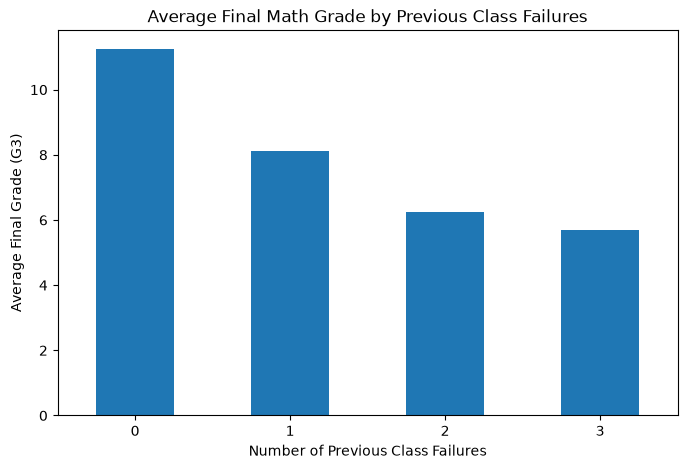

In [20]:
plt.figure(figsize=(8, 5))

df.groupby("failures")["G3"].mean().plot(kind="bar")

plt.title("Average Final Math Grade by Previous Class Failures")
plt.xlabel("Number of Previous Class Failures")
plt.ylabel("Average Final Grade (G3)")
plt.xticks(rotation=0)

plt.show()

## Visualization Analysis

The first visualization shows the average final math grade for each study time category. Students who studied less than 2 hours per week had an average grade of about 10.0, while students studying 5–10 hours had an average of about 11.4. Students studying more than 10 hours had an average of about 11.3. This suggests that students who reported more study time generally had slightly higher final grades, although the difference was not very large. This is consistent with previous research showing that the relationship between study time and academic performance can be relatively weak and may depend on study habits and other factors (Plant et al., 2005; Nonis & Hudson, 2010).

The second visualization shows the relationship between absences and final math grade. The points are spread out, and there is very little linear relationship in this dataset. The correlation between absences and final grade was approximately 0.03. Previous research has found that absences can be related to academic performance, although the strength of this relationship can vary depending on the students and setting (Aucejo & Romano, 2016).

The third visualization shows average final math grade by previous class failures. This graph shows the clearest pattern of the three. Students with no previous failures had an average grade of about 11.3, while students with one, two, or three previous failures had lower average grades. This suggests that previous class failures are more strongly related to final math performance than study time or absences in this dataset.

## Results

### Linear Regression

The linear regression model used study time, absences, and previous class failures to predict final math grades. The model had an R² of about 0.03, meaning that these three variables explained only about 3% of the variation in final grades. The RMSE was about 4.46 points on the 0–20 grading scale.

The model coefficients also showed that previous class failures had the strongest relationship with final grade. The coefficient for failures was about -2.27, meaning that each additional previous failure was associated with about a 2.27-point decrease in predicted final grade when the other variables were held constant.

### Logistic Regression

The logistic regression model predicted whether a student passed or failed based on study time, absences, and previous class failures. The model had an accuracy of about 73.4% on the test data.

The model was better at identifying students who passed than students who failed. Its recall for passing students was about 0.94, while recall for failing students was about 0.33.

### Decision Tree

The decision tree also predicted whether students passed or failed. It achieved an accuracy of about 75.9%, which was slightly higher than the logistic regression model.

The tree showed that previous class failures were an important decision point. Absences and study time were also used to make predictions, but previous failures appeared near the top of the tree, suggesting that this variable was especially useful for classification.

### Overall Findings

Overall, previous class failures showed the clearest relationship with final math performance. Study time had a smaller relationship with grades, while absences showed very little linear relationship with final grade.

The classification models were able to predict passing and failing students with moderate accuracy, with the decision tree performing slightly better than logistic regression. However, the low R² from the linear regression shows that study time, absences, and previous failures alone do not explain most of the differences in students' final grades.

## Limitations and Potential Bias

There are many limitations to this analysis. First, the dataset only includes students from two Portuguese secondary schools, so the results may not apply to students from other schools, countries, or age groups.

Another limitation is that the analysis only uses study time, absences, and previous class failures to predict final grades. Other factors, such as motivation, family support, teaching quality, socioeconomic background, and access to academic resources could also affect student performance.

The study-time variable is reported in categories rather than exact numbers of hours, which limits how precisely study habits can be measured. In addition, the dataset is observational, so the results show relationships between variables but cannot prove that study time, absences, or previous failures directly cause changes in grades.

Finally, the classification models had moderate accuracy rather than perfect accuracy. This suggests that these three variables alone are not enough to accurately predict every student's performance.

## Conceptualization and Operationalization

### Study Time
**Conceptual definition:** Study time refers to the amount of time a student spends studying outside of regular class time.

**Operational definition:** Study time is measured using the dataset's `studytime` variable, which has four categories: less than 2 hours, 2–5 hours, 5–10 hours, and more than 10 hours per week.

### Absences
**Conceptual definition:** Absences represent how often a student misses school.

**Operational definition:** Absences are measured using the `absences` variable, which records the number of school absences for each student.

### Previous Class Failures
**Conceptual definition:** Previous class failures represent a student's history of failing classes before the current course.

**Operational definition:** Previous class failures are measured using the `failures` variable, which records the number of previous class failures from 0 to 3.

### Final Math Grade
**Conceptual definition:** Final math grade represents a student's academic performance in the mathematics course.

**Operational definition:** Final math grade is measured using the `G3` variable, which records the student's final mathematics grade on a scale from 0 to 20.

## References

Aucejo, E. M., & Romano, T. F. (2016). Assessing the effect of school days and absences on test score performance. *Economics of Education Review, 55*, 70–87. https://doi.org/10.1016/j.econedurev.2016.08.007

Nonis, S. A., & Hudson, G. I. (2010). Performance of college students: Impact of study time and study habits. *Journal of Education for Business, 85*(4), 229–238. https://doi.org/10.1080/08832320903449550

Plant, E. A., Ericsson, K. A., Hill, L., & Asberg, K. (2005). Why study time does not predict grade point average across college students: Implications of deliberate practice for academic performance. *Contemporary Educational Psychology, 30*(1), 96–116. https://doi.org/10.1016/j.cedpsych.2004.06.001

UCI Machine Learning Repository. (2008). *Student performance* [Dataset]. https://doi.org/10.24432/C5TG7T

The first visualization shows the average final math grade for each study time category. Students who studied less than 2 hours per week had an average grade of about 10.0, while students studying 5–10 hours had an average of about 11.4. Students studying more than 10 hours had an average of about 11.3. This suggests that students who reported more study time generally had slightly higher final grades, although the difference was not very large. This is consistent with previous research showing that the relationship between study time and academic performance can be relatively weak and may depend on study habits and other factors (Plant et al., 2005; Nonis & Hudson, 2010).

The second visualization shows the relationship between absences and final math grade. The points are spread out, and there is very little linear relationship in this dataset. The correlation between absences and final grade was approximately 0.03. Previous research has found that absences can be related to academic performance, although the strength of this relationship can vary depending on the students and setting (Aucejo & Romano, 2016).

## Data Cleaning

I loaded the CSV file using pandas and specified `sep=";"` because the dataset uses semicolons to separate values. I inspected the dataset using `df.head()` and `df.info()` to check its structure and data types.

I also checked for missing values using `df.isnull().sum()`. The dataset contained no missing values, so I did not need to remove rows or fill in missing values.

For this analysis, I kept the original values for study time, absences, previous class failures, and final grade. Changing these values could remove useful information from the dataset.

I also created a binary `passed` variable for the classification models. For this project, I defined a passing grade as `G3 >= 10`. This is an operational definition used for this analysis, so the classification results depend on this threshold.

## AI Usage Disclosure

I used ChatGPT to help brainstorm the research question, explain Python code and model outputs, troubleshoot coding errors, and improve the organization and wording of this project. I reviewed the suggestions and ran the analysis myself in Python.